

### This is a demo of how to use the built-in sapphire tree reading modules to create a compactified npz binary file. The resulting file contains a dict indexed by root halo ID mapped to an astropy table giving relevant halo properties vs time. This compactified npz file can be more quickly and easily read in during subsequent sapphire runs compared to reading in the gigantic original tree files. Currently only the main progenitor's properties are tracked.

There are plans to improve this further when Viraj merges in the JAX code (writing a simpler/faster customized tree reader instead of ytree, doing away with astropy tables in terms of interpolator objects, accounting for non-main branches, allowing for non-FIRE/non-TNG/non-consistent-trees files, EPS/SatGen, etc.). 

In [6]:
%matplotlib inline

from sapphire.read_trees import read_tng, interpolate_trees
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set up the parameters dict for sapphire to tell it the path to the TNG isotrees and what subvolumes to read in

# Previously I was only reading in 5 subvolumes (000-004) but that only leads to a handful of logmvir>12 halos
# but for the BH hacks with Bryan, Sophie, Aaron, we need more massive group/cluster halos


parameters = {'output_path':'/mnt/ceph/users/vpandya/sapphire/data', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care of writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4','0_1_0','0_1_1','0_1_2','0_1_3','0_1_4'],
              'num_readers':5,
              'num_writers':5,
              'min_root_mass':1e10} # relevant for TNG, not for FIRE


In [3]:
# call read_tng.read_trees which will return a dict of roothaloid:astropy.table pairs
# this can take a long time depending on how many tree files you are reading in (since ytree is slow)

tstart = timer()
tables_tng = read_tng.read_trees(parameters)

print('Finished in %s sec'%(timer()-tstart))

Reading in trees for subvolume=0_0_2Reading in trees for subvolume=0_0_0Reading in trees for subvolume=0_0_1Reading in trees for subvolume=0_0_3Reading in trees for subvolume=0_0_4




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_4.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_3.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)



Loading tree roots:   0%|          | 0/1556351529 [00:00<?, ?it/s]

Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_2.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_0.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)


Loading tree roots:   1%|          | 10165897/1556351529 [00:00<00:15, 99626769.22it/s]

Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_1.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)


...

Loading tree roots: 100%|██████████| 1807233880/1807233880 [00:05<00:00, 328774180.26it/s]


Reading in trees for subvolume=0_1_3


Loading tree roots: 100%|██████████| 2090213278/2090213278 [00:06<00:00, 329206509.37it/s]


Reading in trees for subvolume=0_1_4


Loading tree roots: 100%|██████████| 4738671033/4738671033 [00:13<00:00, 347619452.00it/s]


14329 14.820038813604468 10.169154807691388


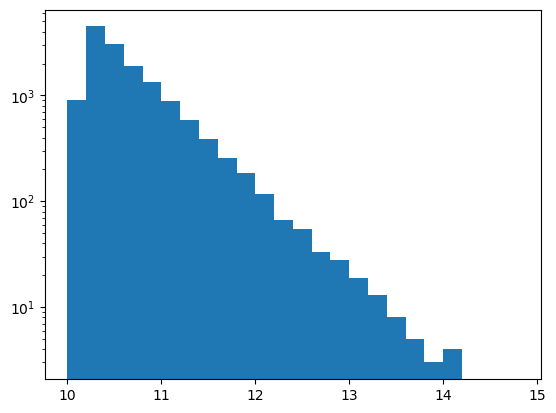

In [7]:
### plot hist of how many halos we have vs. root halo mass

root_logmvir = [tree['log_mvir'][-1] for haloid,tree in tables_tng.items()]
print(len(root_logmvir), np.max(root_logmvir), np.min(root_logmvir))

_ = plt.hist(root_logmvir,bins=np.arange(10,15,0.2))
plt.yscale('log')

In [9]:
### finally, just np.savez this resulting dict

outpath = '/mnt/ceph/users/vpandya/sapphire/data/tng_trees_compactified_10subvolumes.npz'

np.savez(outpath,
         tables_tng=tables_tng)

In [18]:
### try re-loading just to test

npz = np.load(outpath,allow_pickle=True)
test_tng = npz['tables_tng'].item() # this is a dict of astropy tables indexed by root halo ID -- sapphire knows how to work with this, see ipynbs under demo/
npz.close()


In [19]:
type(test_tng), len(test_tng)

(dict, 14329)

14329 14.820038813604468 10.169154807691388


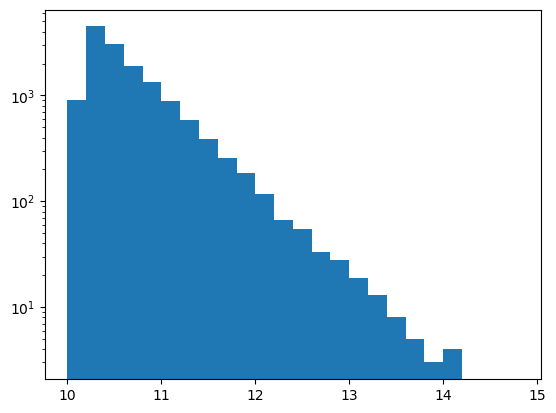

In [20]:
### test -- remake same histplot above

root_logmvir = [tree['log_mvir'][-1] for haloid,tree in test_tng.items()]
print(len(root_logmvir), np.max(root_logmvir), np.min(root_logmvir))

_ = plt.hist(root_logmvir,bins=np.arange(10,15,0.2))
plt.yscale('log')